# Analysis of Colors in Popular English Romance Movies

## Project Goals: The Colors of Romance

### Introduction
The Colors of Romance project aims to explore the relationship between color palettes and the emotional tone of romance movies across different languages. By analyzing the dominant colors used in popular romance films in English, Korean, and Hindi. This project seeks to uncover whether the language and cultural context influence the color schemes associated with love and romance.

### Whats already done:
**Data Collection:**
Extract frames from the top 25 romance movies in each language category.
Identify the dominant colors in each frame using a consistent methodology.

**Data Organization:**
Store the dominant color data for each movie in separate CSV files, with each file corresponding to one movie.

### What's left to do:

**Color Analysis:**
Perform clustering analysis (e.g., K-Means in this notebook) to identify common color patterns within and across language categories. Compare the color palettes across different languages to see if there are significant differences in how romance is visually represented.

**Visualization:**
Create visual representations (e.g., color histograms, cluster visualizations) to illustrate the dominant colors and patterns found in the analysis.

**Interpretation:**
Interpret the results to draw conclusions about the influence of language and cultural context on the color choices in romance films. Explore whether certain color palettes are more prevalent in one language category compared to others.

**Reporting:**
Document the findings in a comprehensive report, supported by visualizations and statistical analysis.
Discuss potential implications for film studies, cultural analysis, and color theory.

## Imports

In [118]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter
import matplotlib.cm as cm
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px

## Loading the Datasets

In [119]:

# Path to the directory containing the CSV files
directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Hindi-Analysis/Hindi-Movie-CSVs'

# List to hold each DataFrame
dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    file_path = os.path.join(directory_path, f'{i}.csv')
    df = pd.read_csv(file_path)
    # Drop columns with NaN values
    df = df.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df['movie_id'] = i
    
    dfs.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Display the combined DataFrame to ensure it looks correct
display(combined_df.head())


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,117,55,10,232,219,96,231,90,12,...,136,91,33,180,162,100,180,173,96,1
1,output_0000002.png,4,4,4,8,4,4,8,4,4,...,8,4,4,8,4,4,8,4,4,1
2,output_0000003.png,199,163,104,17,17,8,170,130,77,...,27,69,69,108,140,132,100,148,134,1
3,output_0000004.png,168,147,89,106,90,47,9,9,6,...,187,5,47,89,122,140,44,61,73,1
4,output_0000005.png,37,49,32,186,199,163,135,139,109,...,88,106,100,130,162,156,192,26,50,1


## Initial Visualization

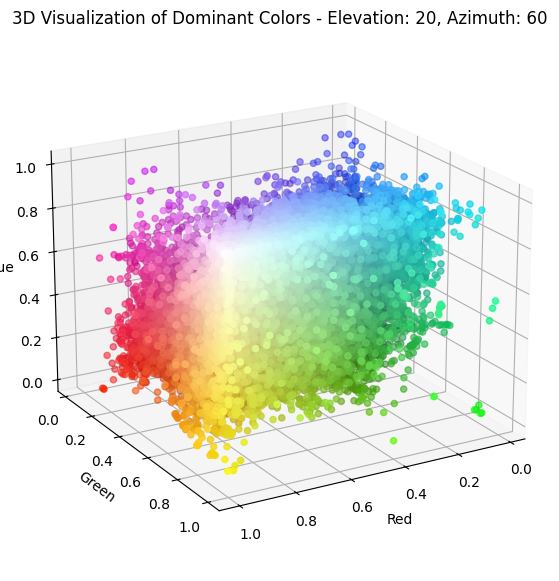

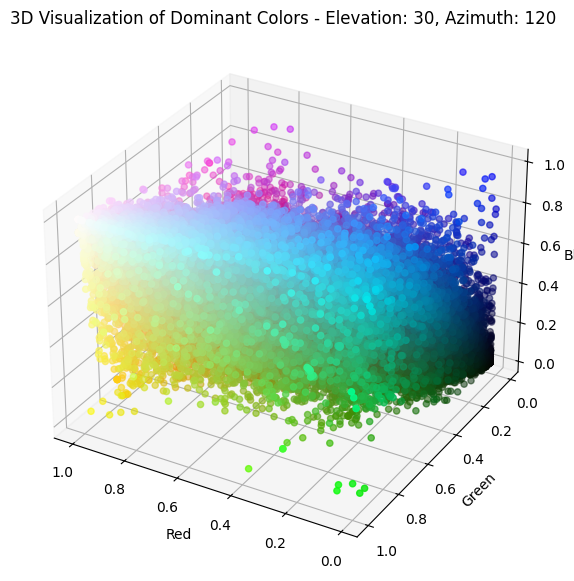

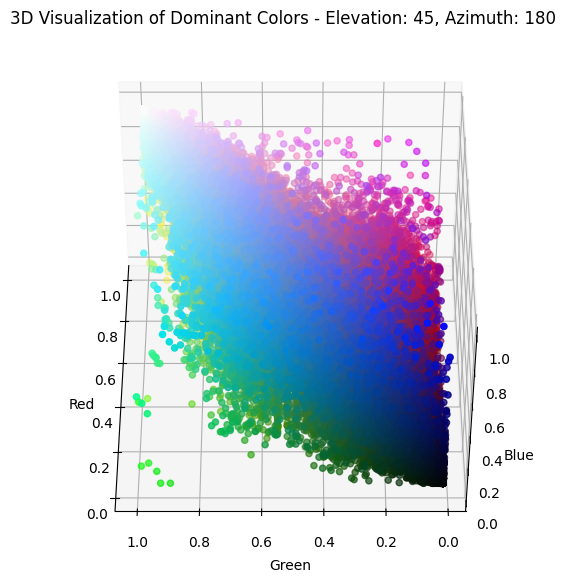

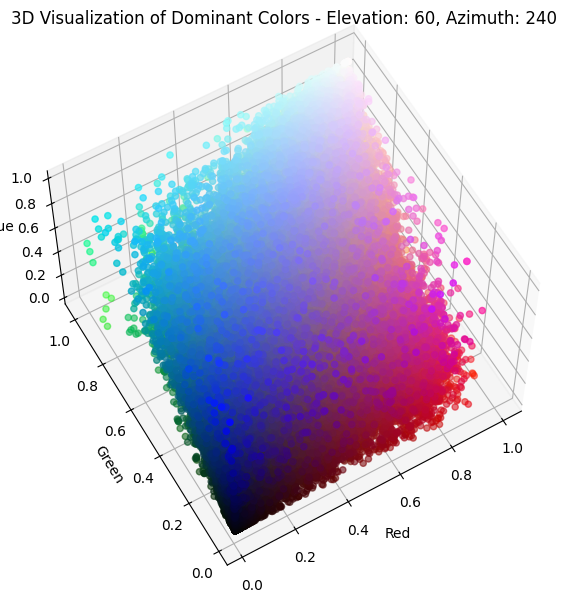

In [120]:
# Create a list of angles to view from
angles = [(20, 60), (30, 120), (45, 180), (60, 240)]

# Extract the RGB values for all 9 dominant colors
r = combined_df[['color_1_r', 'color_2_r', 'color_3_r', 'color_4_r', 'color_5_r', 'color_6_r', 'color_7_r', 'color_8_r', 'color_9_r']].values.flatten()
g = combined_df[['color_1_g', 'color_2_g', 'color_3_g', 'color_4_g', 'color_5_g', 'color_6_g', 'color_7_g', 'color_8_g', 'color_9_g']].values.flatten()
b = combined_df[['color_1_b', 'color_2_b', 'color_3_b', 'color_4_b', 'color_5_b', 'color_6_b', 'color_7_b', 'color_8_b', 'color_9_b']].values.flatten()

# Normalize RGB values and clip to ensure they are within [0, 1]
r_normalized = np.clip(r / 255.0, 0, 1)
g_normalized = np.clip(g / 255.0, 0, 1)
b_normalized = np.clip(b / 255.0, 0, 1)

# Create 3D plots from different angles
for elev, azim in angles:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot
    ax.scatter(r_normalized, g_normalized, b_normalized, c=[(r_val, g_val, b_val) for r_val, g_val, b_val in zip(r_normalized, g_normalized, b_normalized)], marker='o')
    
    # Set labels
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    
    # Set plot title
    ax.set_title(f'3D Visualization of Dominant Colors - Elevation: {elev}, Azimuth: {azim}')
    
    # Set the viewing angle
    ax.view_init(elev=elev, azim=azim)
    
    # Show the plot
    plt.show()

Hmm so from this intial plot it doesnt seem to show us anything indicative of a specific color profile being preferre, but lets not make any conclusions here.

## Dominant Color per frame plotted

Here i just want to plot the dominant color per frame for each movie just to get an idea of what colors i expect to see in the clusterings.

Also to explain, some movies have fewer frames as a result of the scene detect algorithm, which only grabs frames when theres been a significant change in the color profile between frames. Movies where this happens less often, will therefore have fewer frames.

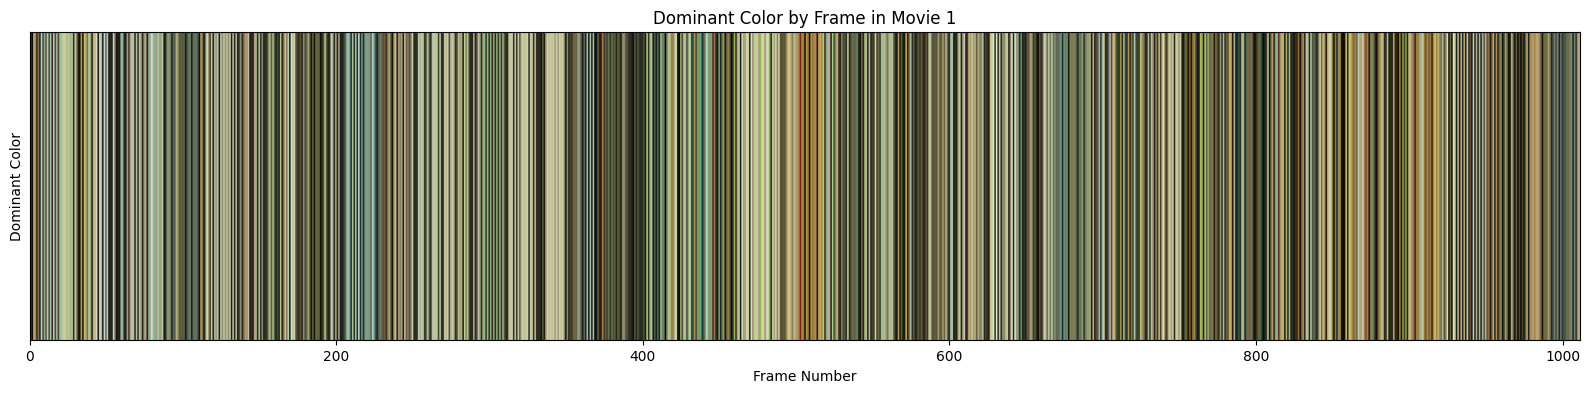

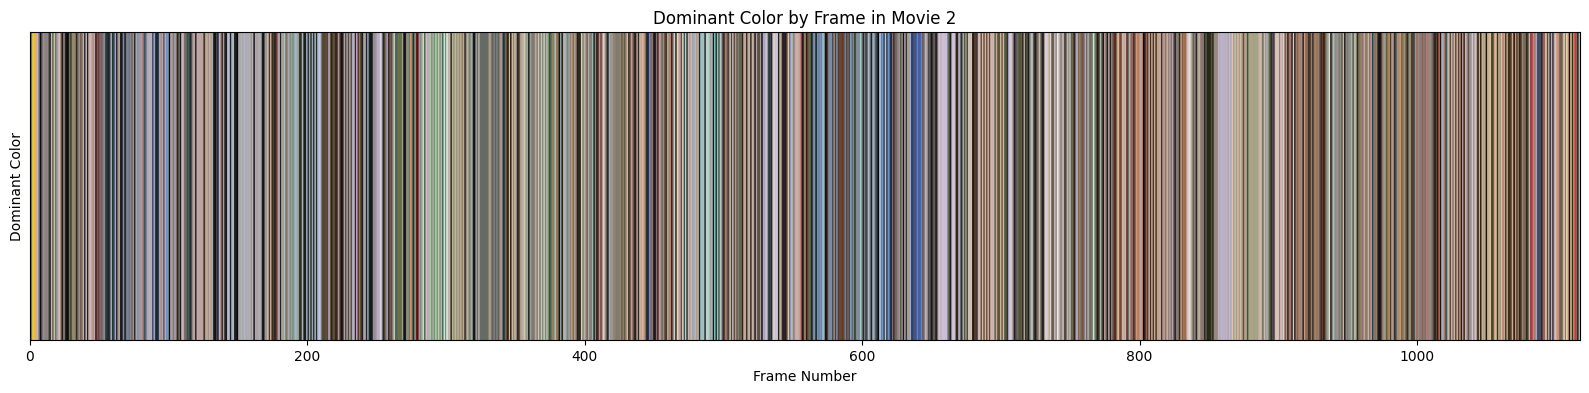

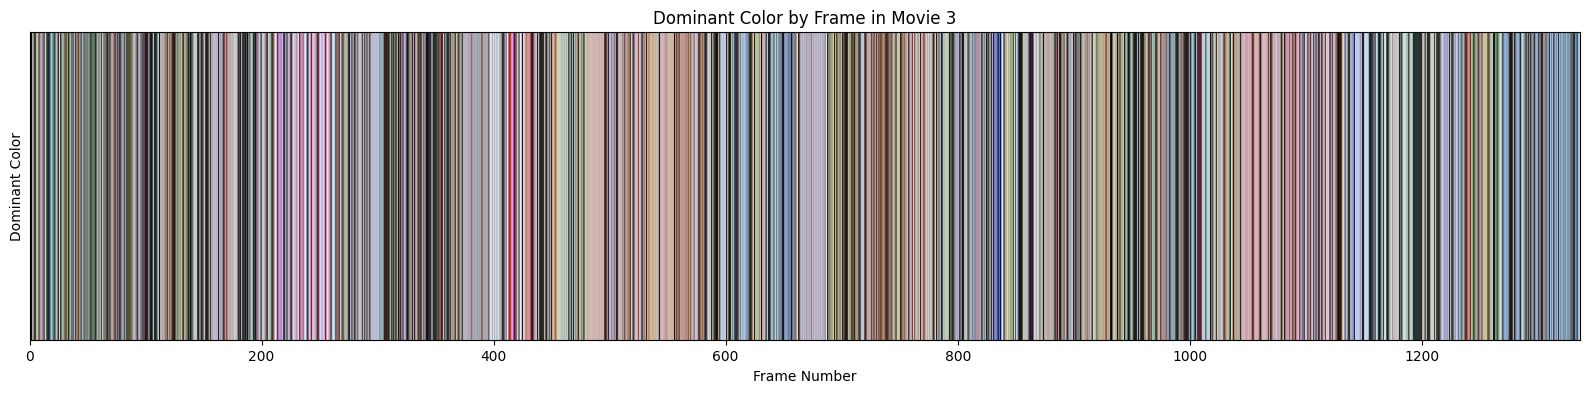

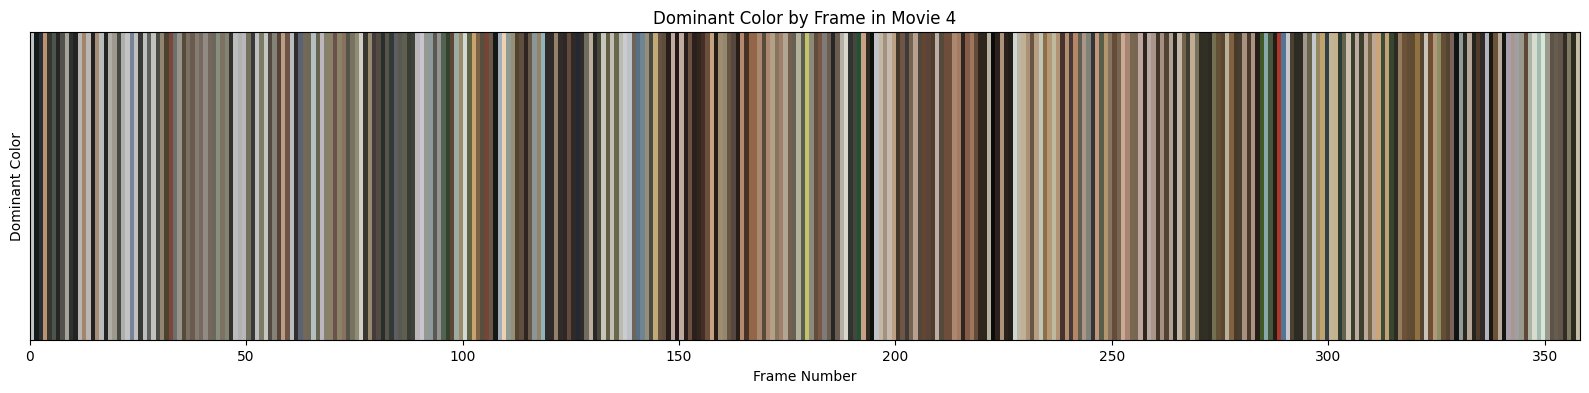

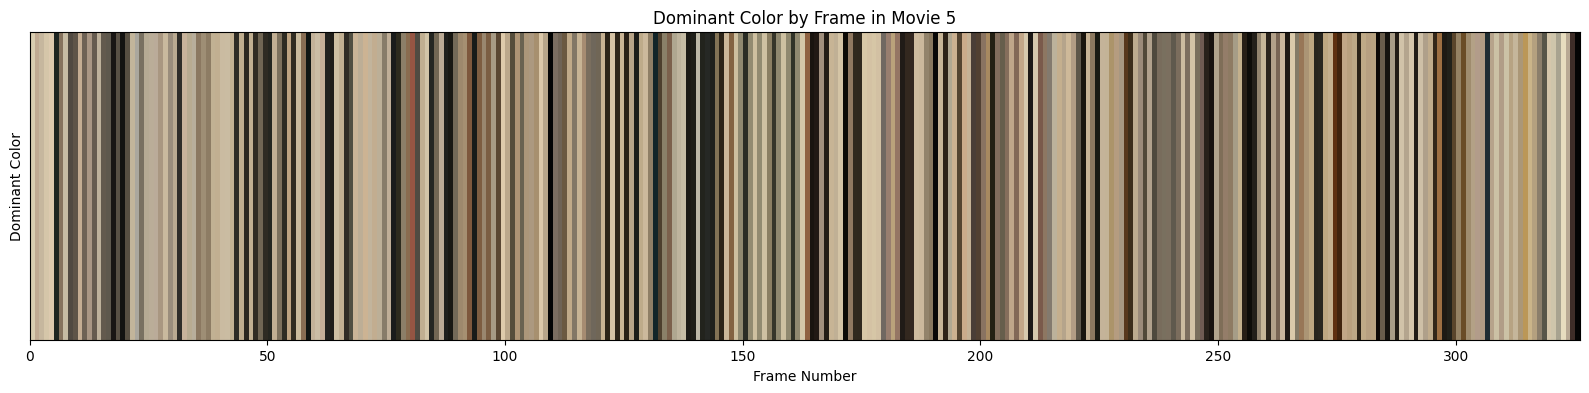

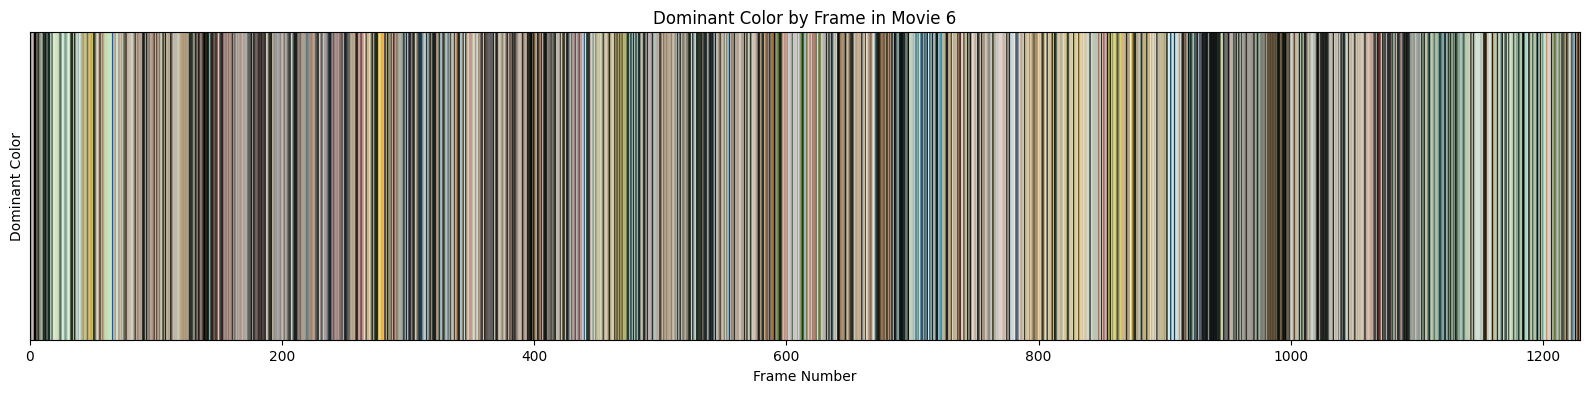

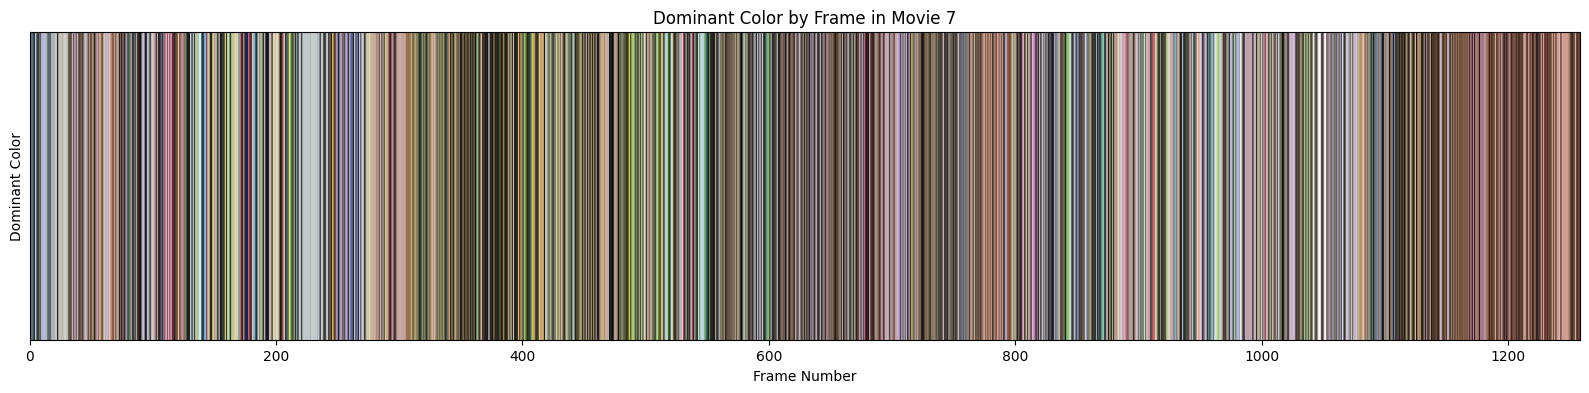

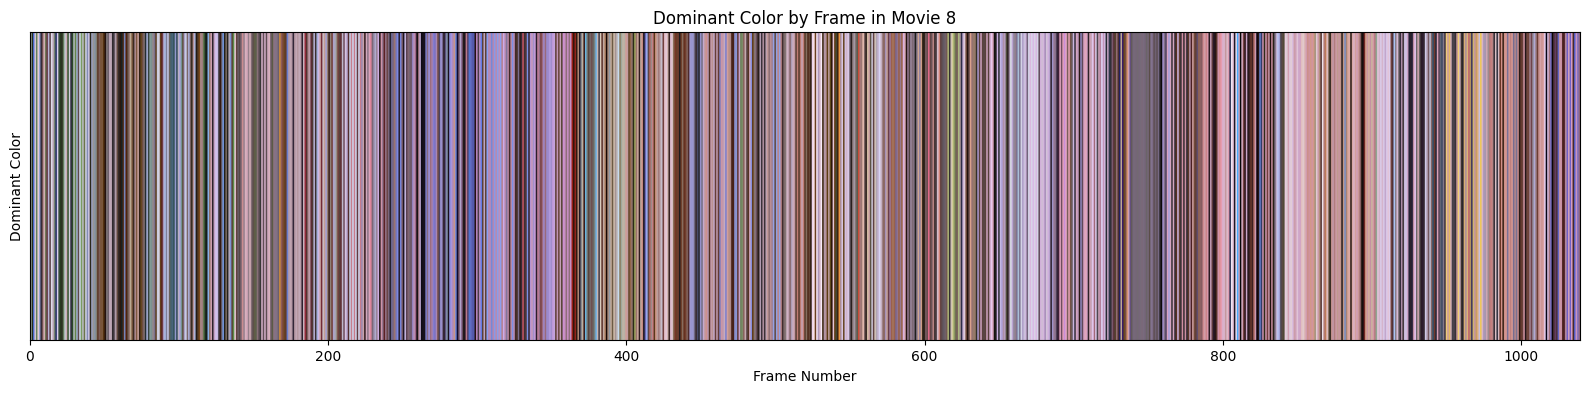

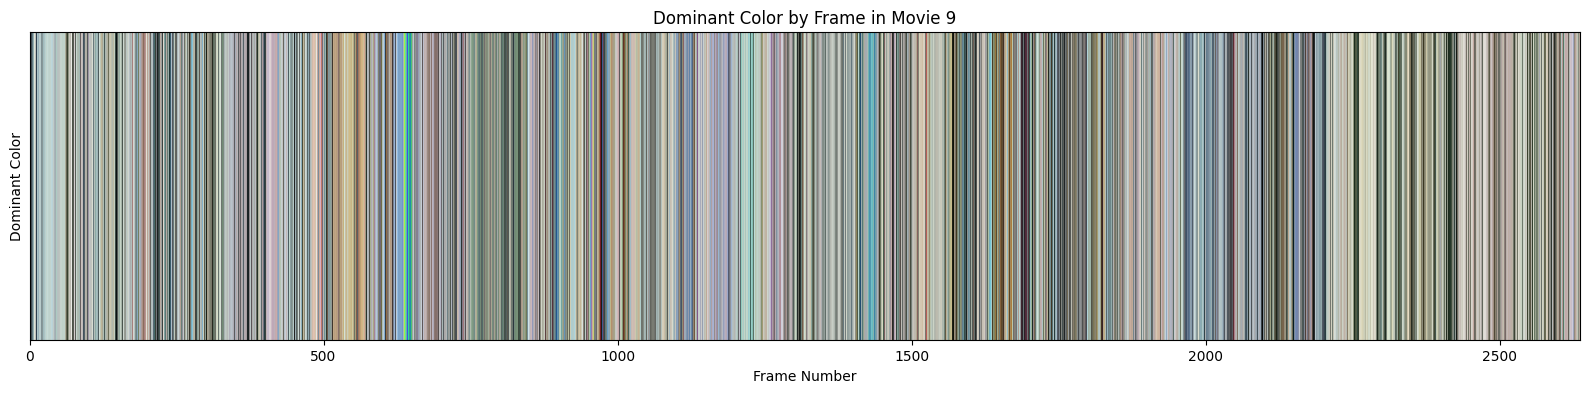

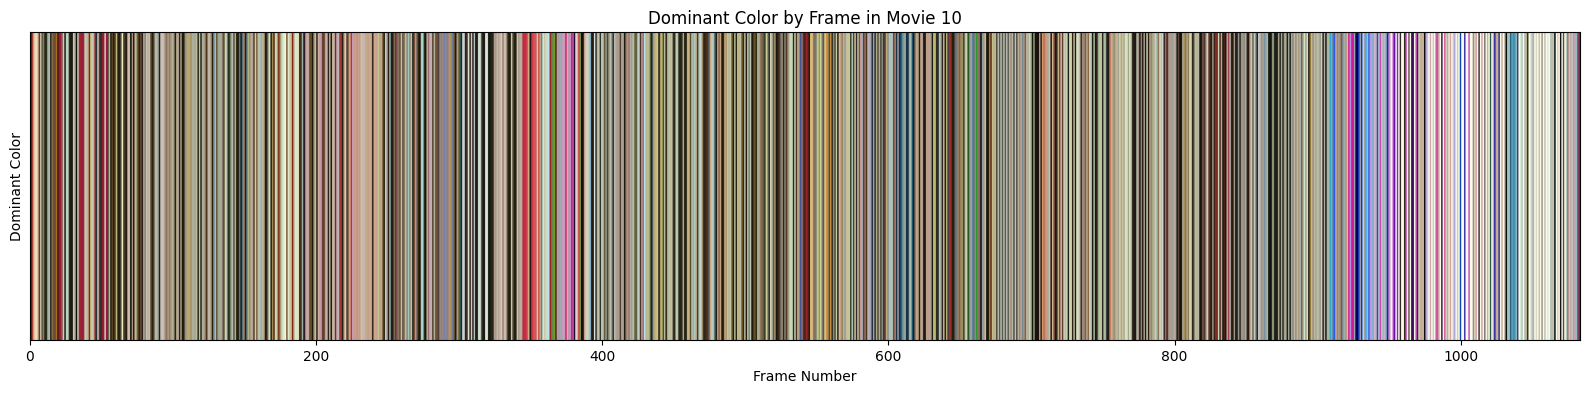

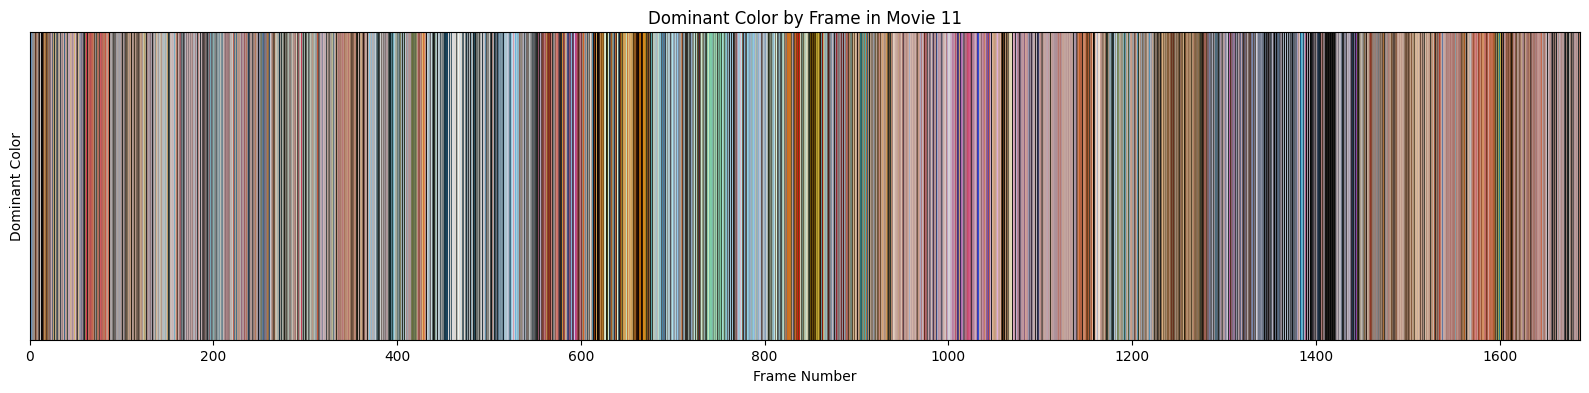

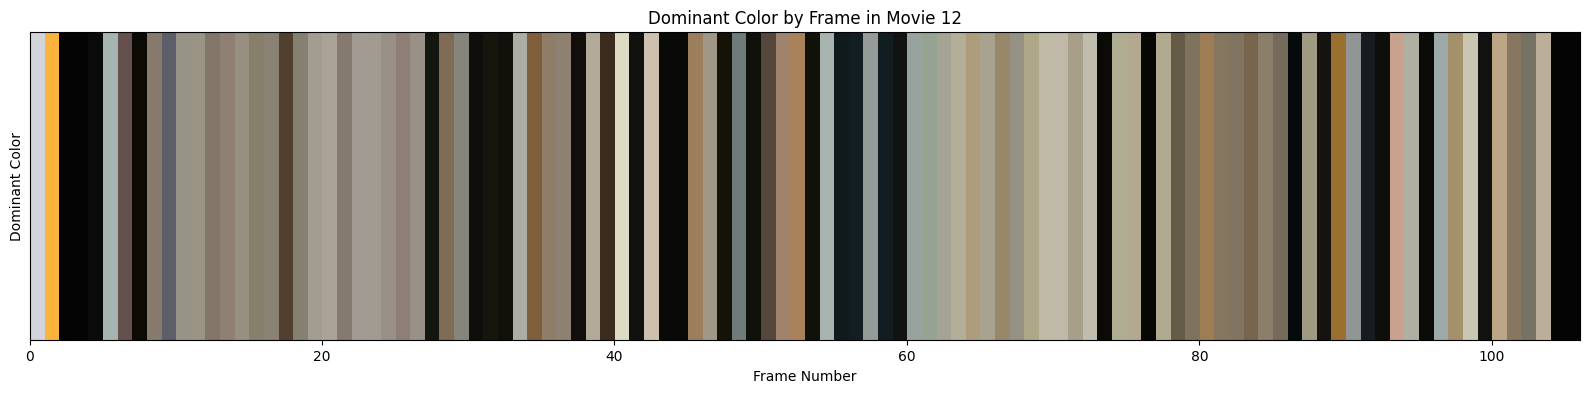

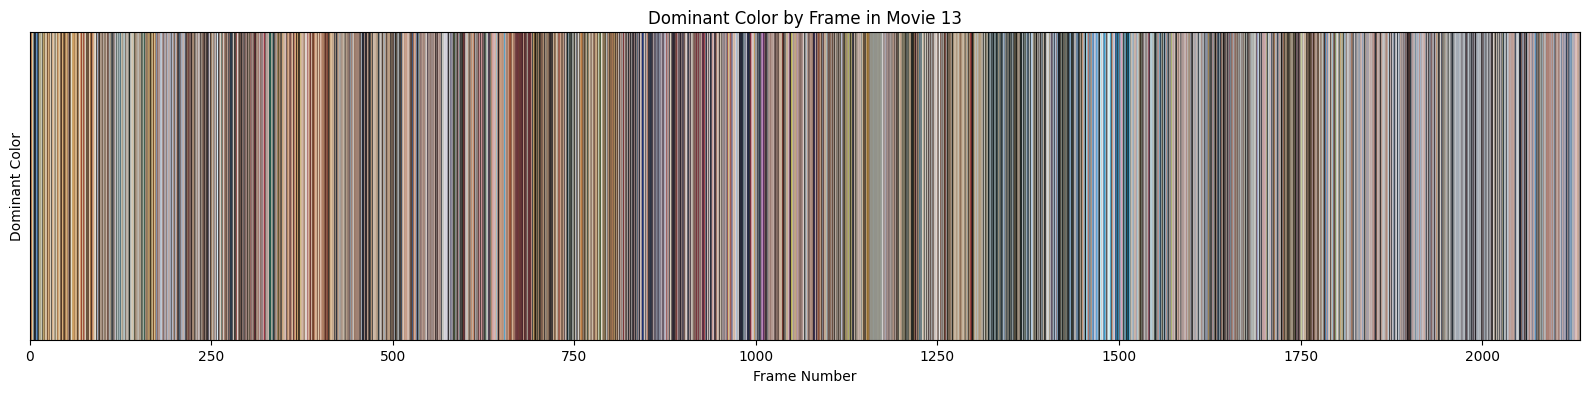

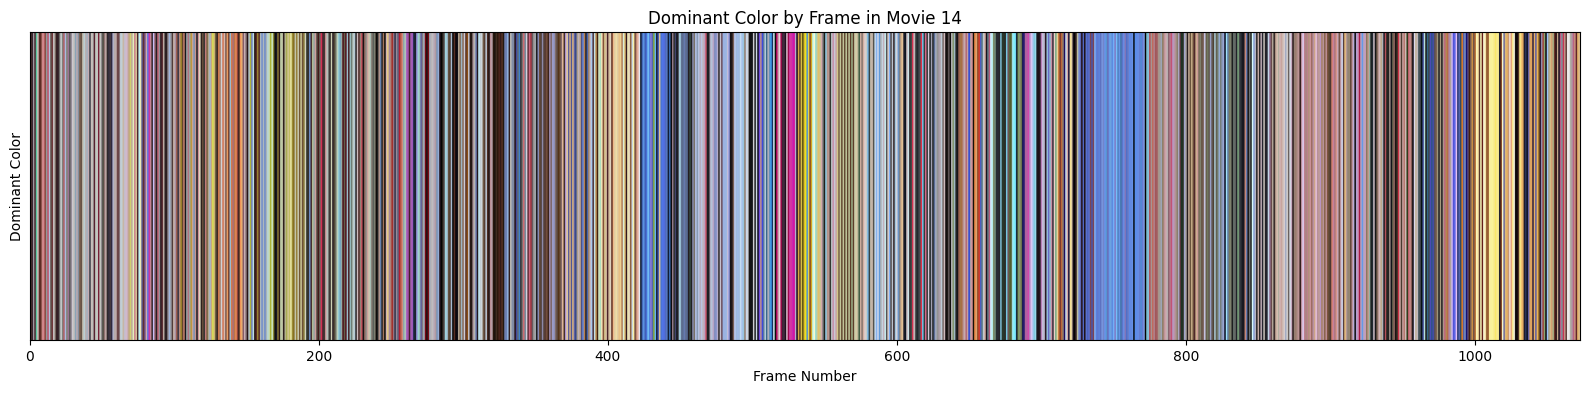

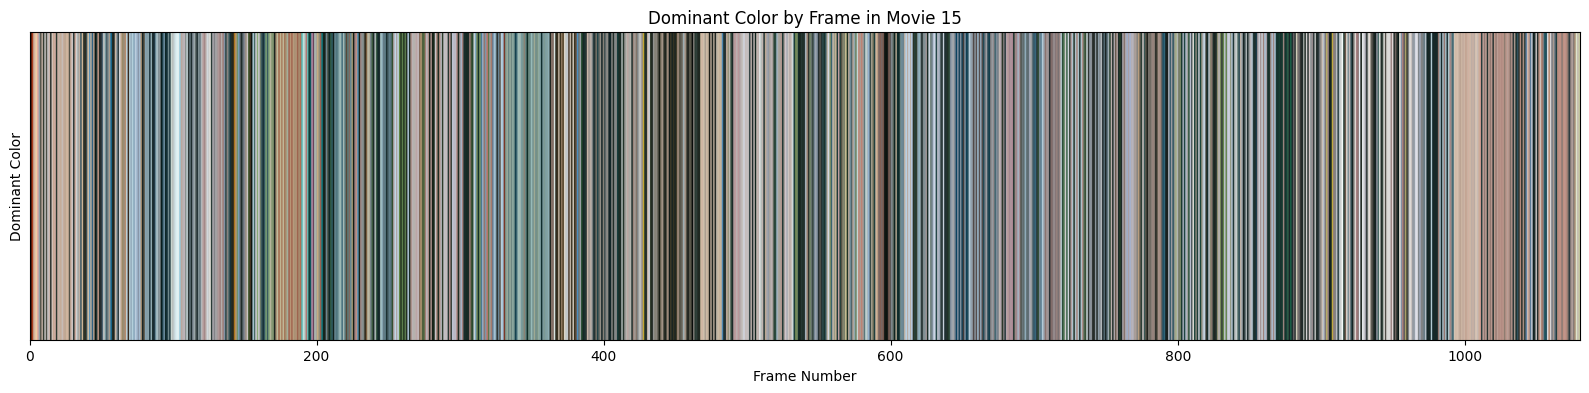

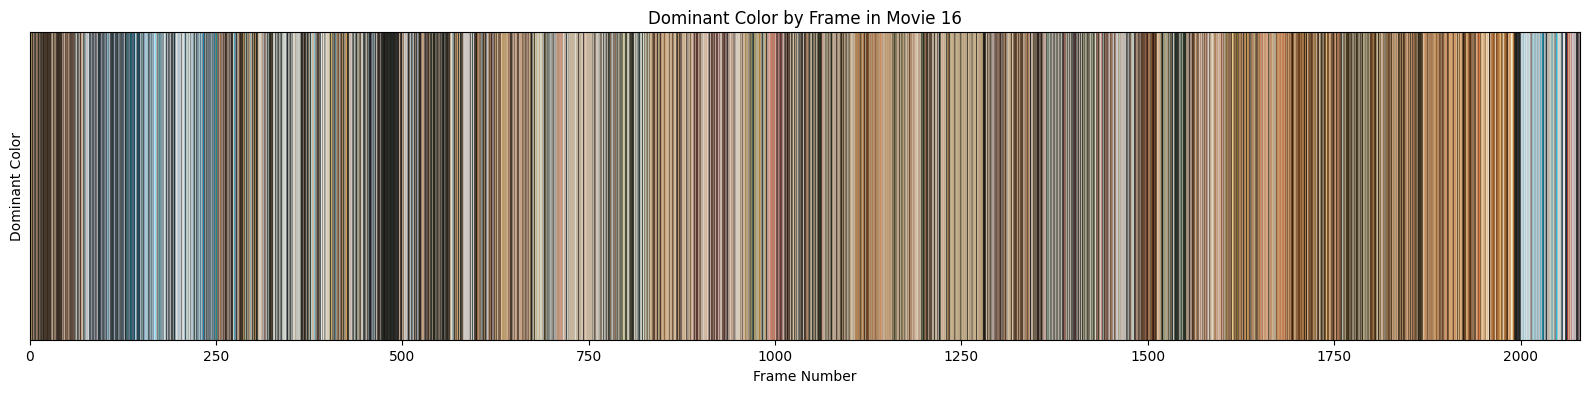

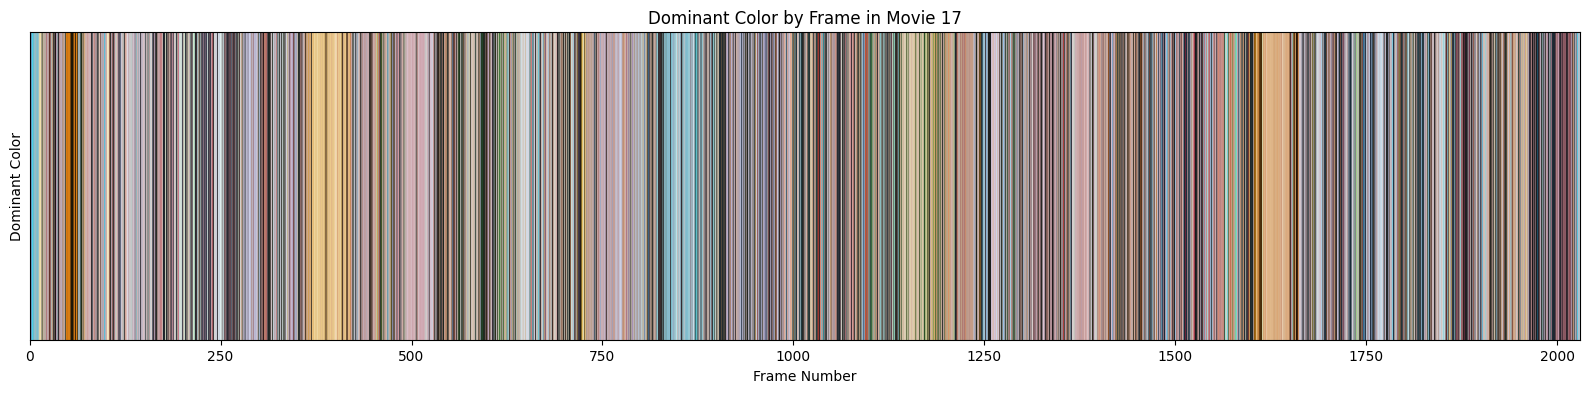

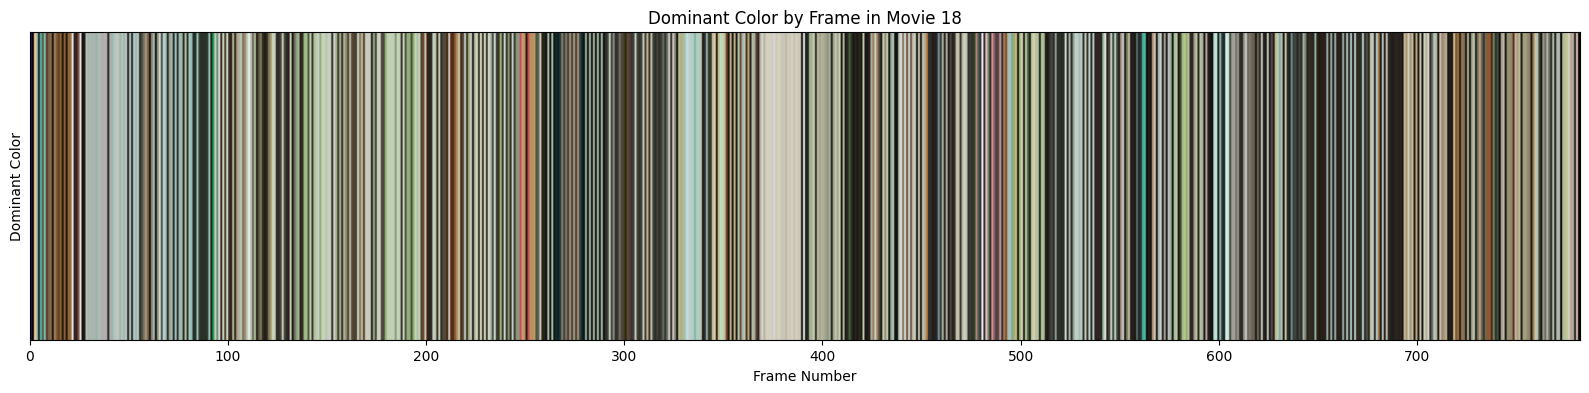

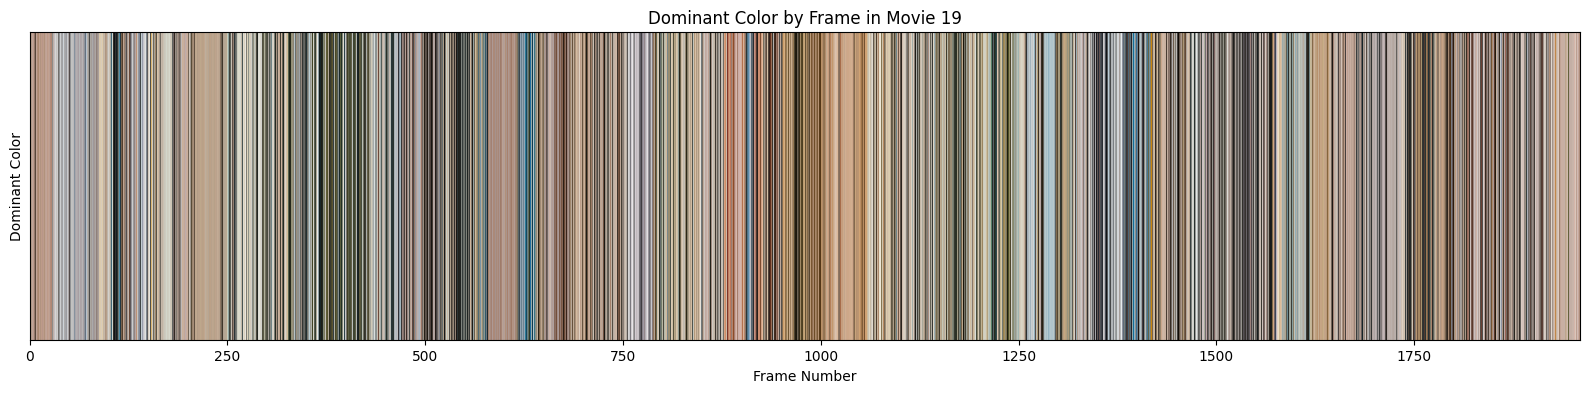

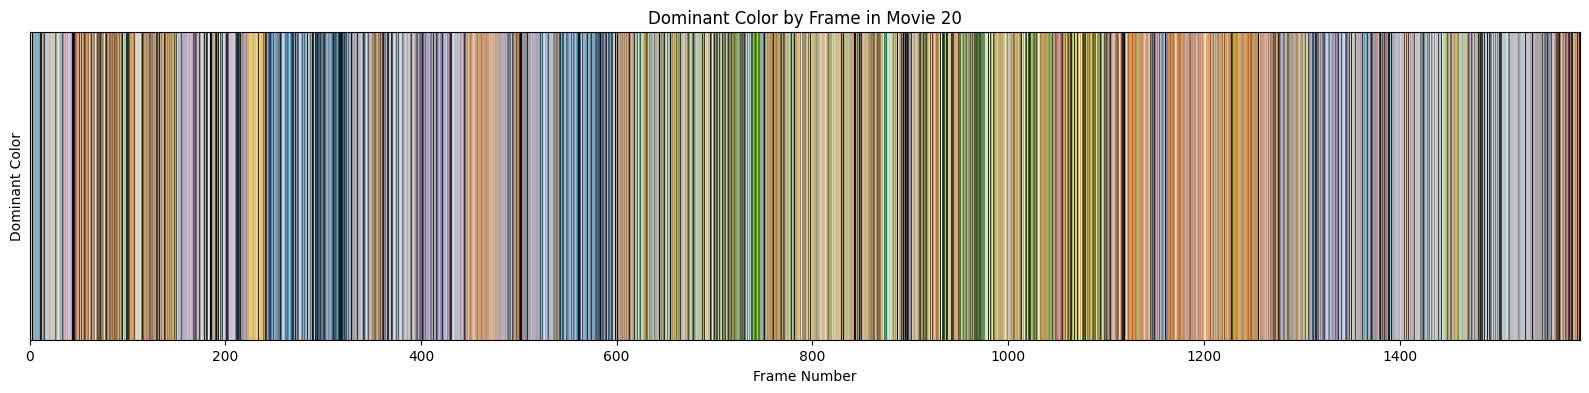

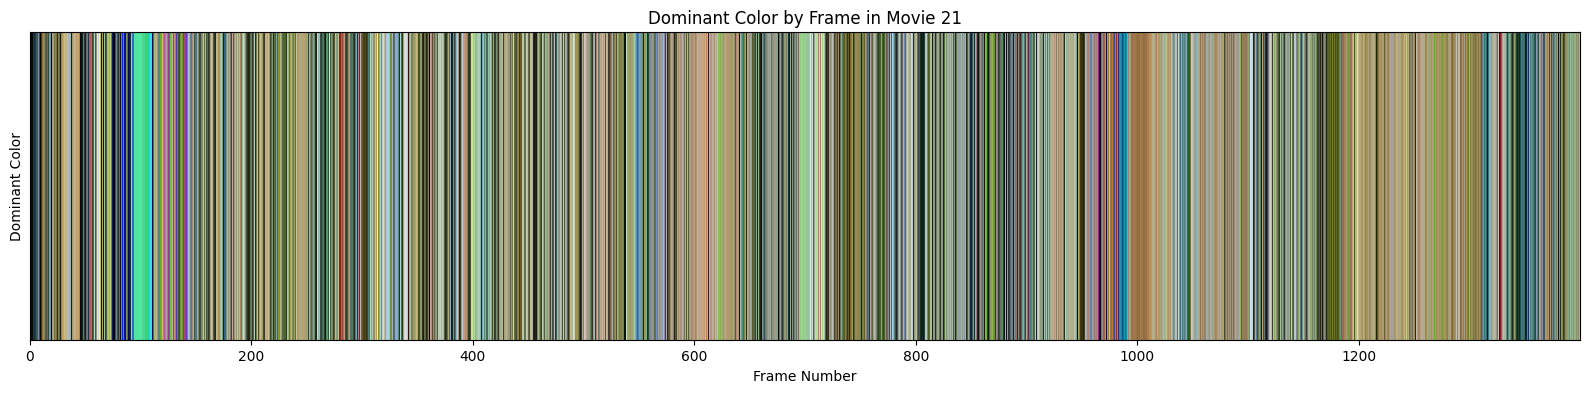

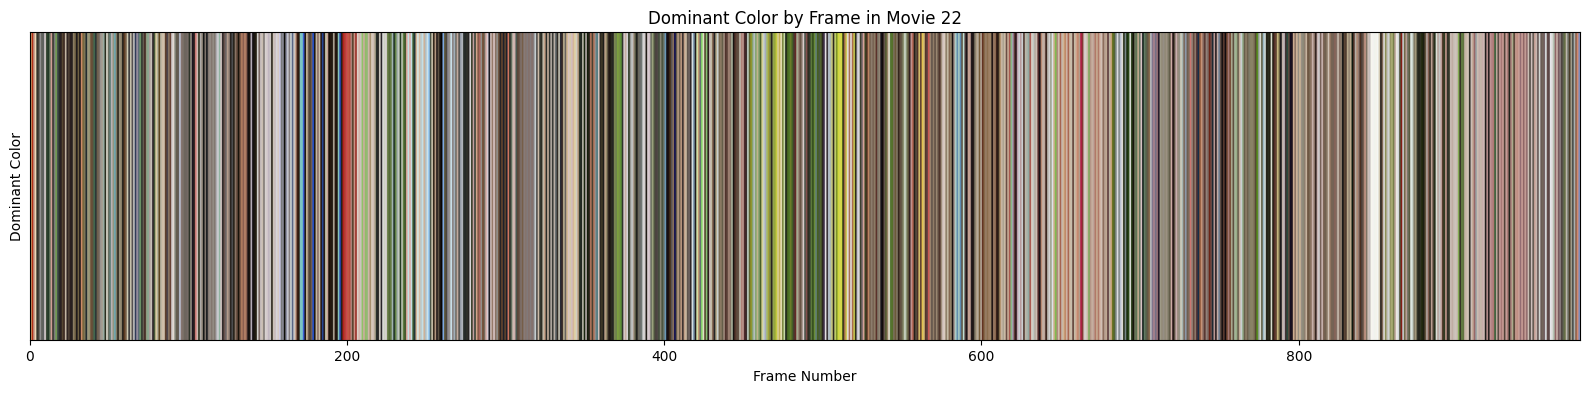

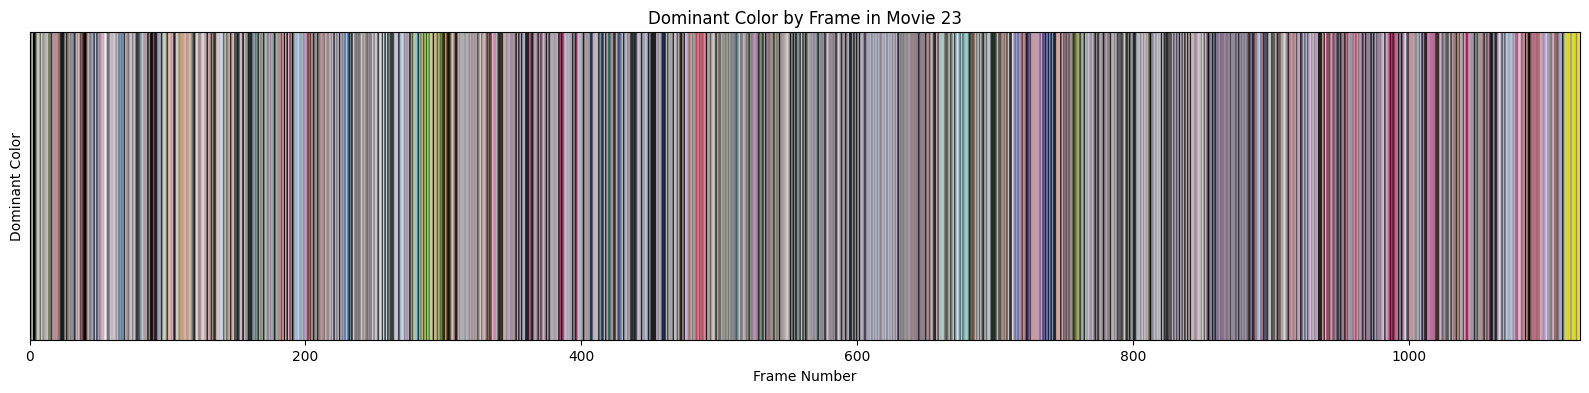

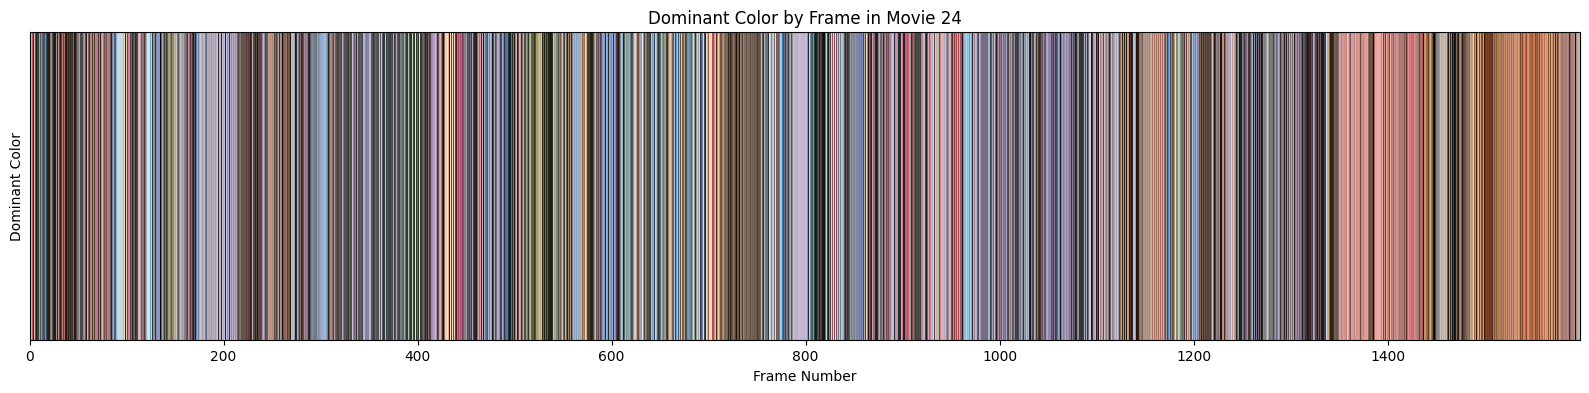

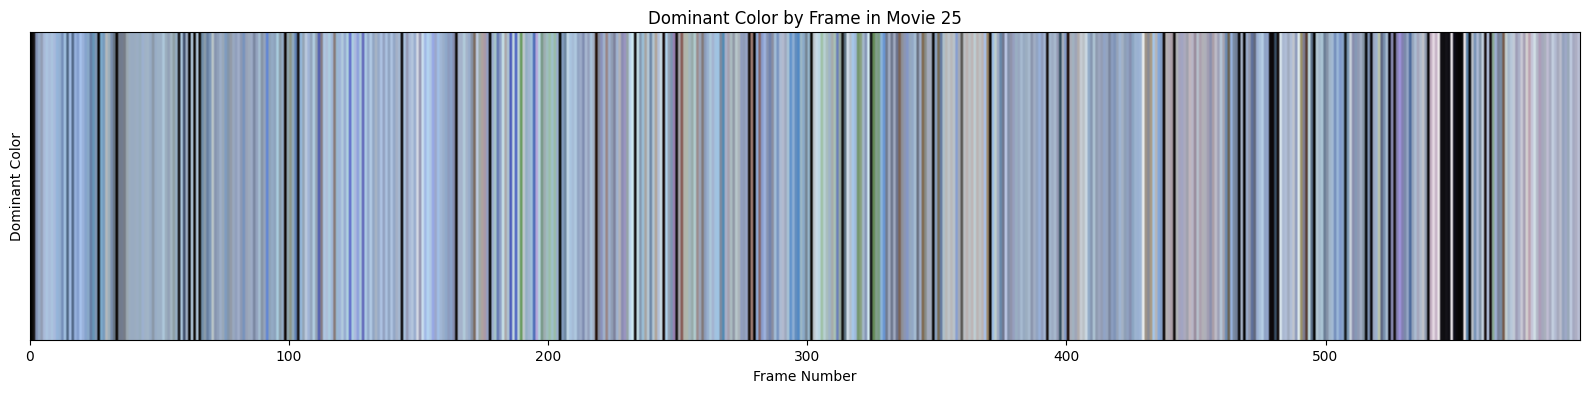

In [121]:
#loop through each movie and plot the dominant color by frame
for movie_id, movie_data in combined_df.groupby('movie_id'):
    # Extract frame numbers and dominant colors for plotting
    frame_numbers = np.arange(len(movie_data))
    dominant_colors_rgb = np.array(movie_data[['color_1_r', 'color_1_g', 'color_1_b']])
    
    # Create the heatmap
    plt.figure(figsize=(20, 4))
    plt.imshow([dominant_colors_rgb], aspect='auto', extent=[0, len(frame_numbers), 0, 1])
    plt.xlabel('Frame Number')
    plt.ylabel('Dominant Color')
    plt.title(f'Dominant Color by Frame in Movie {movie_id}')
    plt.yticks([])
    plt.show()

## K-Means Analysis

I know from the K-means analysis I did on the Ghibli project that the lower the numbers of clusters, the more muted the color of each cluster centre. As stated last time this probably has to do with it averaging more muted tones due to the reduced of clusters. So im going to choose 15 ish clusters.

### The Plan

**Step-by-Step K-Means Analysis:**

1. **Segment Each Movie into x Parts:** We are doing this to get a more diverse understanding of the colors across each movie.

2. **Cluster Colors Within Each Segment:** Apply K-Means clustering to the colors within each segment.

3. **Cluster Segment Centers for Each Movie:** Cluster the cluster centers from each segment to identify dominant color themes for the entire movie.

4. **Final Clustering Across All Movies:** Take the cluster centers from each movie and perform another round of clustering to find common color themes across all movies.

### Step 1: Cluster Colors Within Each Segment

*Segment the movies first*

In [122]:
# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
combined_df['segment_id'] = combined_df.groupby('movie_id').cumcount() // (combined_df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

In [123]:
display(combined_df)

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,117,55,10,232,219,96,231,90,12,...,91,33,180,162,100,180,173,96,1,0
1,output_0000002.png,4,4,4,8,4,4,8,4,4,...,4,4,8,4,4,8,4,4,1,0
2,output_0000003.png,199,163,104,17,17,8,170,130,77,...,69,69,108,140,132,100,148,134,1,0
3,output_0000004.png,168,147,89,106,90,47,9,9,6,...,5,47,89,122,140,44,61,73,1,0
4,output_0000005.png,37,49,32,186,199,163,135,139,109,...,106,100,130,162,156,192,26,50,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31596,output_0000594.png,153,168,184,190,203,219,131,137,159,...,71,90,71,56,48,198,69,69,25,4
31597,output_0000595.png,191,202,223,139,147,165,17,16,17,...,51,48,140,142,135,77,77,72,25,4
31598,output_0000596.png,165,169,193,102,103,113,150,116,116,...,52,62,61,84,46,60,67,159,25,5
31599,output_0000597.png,174,175,196,142,144,159,105,109,120,...,57,61,66,76,78,101,116,172,25,5


In [124]:
# Group by movie_id and segment_id and count the number of frames in each segment
frame_counts = combined_df.groupby(['movie_id', 'segment_id']).size().reset_index(name='frame_count')

# Display the result
display(frame_counts)

,movie_id,segment_id,frame_count
0,1,0,202
1,1,1,202
2,1,2,202
3,1,3,202
4,1,4,202
...,...,...,...
144,25,1,119
145,25,2,119
146,25,3,119
147,25,4,119


What this tells me is that there are certain segments with very few frames, in this case we can we can add a min_threshold, so lets say if there are less than 5 frames we skip, so less than 50 colors to cluster on. Otherwise we dynamically change the clusters size to match the frames.

In [125]:


# Define the number of clusters for each segment
num_clusters_per_segment = 15  # You can adjust this number

# Define the threshold for the minimum number of frames to perform clustering
# min_frames_threshold = 6  # You can adjust this threshold

# Create a list to hold all cluster centers
all_cluster_centers = []

# Group the data by movie and segment
grouped = combined_df.groupby(['movie_id', 'segment_id'])

for (movie_id, segment_id), group in grouped:
    # Reshape the data to have each color as an individual row
    colors = []
    for i in range(1, 10):  # Looping through the top 9 dominant colors
        colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)

    # Combine all the colors into a single array
    colors_array = np.vstack(colors)

    # Check if there are enough data points to perform clustering
    if len(colors_array) >= num_clusters_per_segment:
        # Perform K-Means clustering on the colors within this segment
        kmeans = KMeans(n_clusters=num_clusters_per_segment,n_init='auto', random_state=42)
        kmeans.fit(colors_array)
        
        # Store the cluster centers
        all_cluster_centers.append(kmeans.cluster_centers_)
    else:
        print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")



Skipping segment 5 of movie 1 due to insufficient data points.
Skipping segment 5 of movie 3 due to insufficient data points.
Skipping segment 5 of movie 5 due to insufficient data points.
Skipping segment 5 of movie 9 due to insufficient data points.
Skipping segment 5 of movie 12 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning:

Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.



### Visualizing the colors found

In [126]:
# Combine all the cluster centers into a single array
all_cluster_centers = np.vstack(all_cluster_centers)

# Convert RGB values to HEX and HSV
hex_colors = []
hsv_colors = []

for r, g, b in all_cluster_centers:
    hex_color = mcolors.to_hex([r/255, g/255, b/255])
    hsv_color = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    
    hex_colors.append(hex_color)
    hsv_colors.append(hsv_color)

# Sort colors by HSV values (primarily by hue)
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_hex_colors = [hex_colors[i] for i in sorted_indices]

# Set the number of columns in the grid
num_columns = 20 

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_hex_colors) / num_columns)

# Adjust the HTML table to be more responsive
html_table = '<table style="border-collapse: collapse; width:100%;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_hex_colors):
            hex_color = sorted_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:5%; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'


# Display the HTML table
display(HTML(html_table))

# Colors are displayed Left to Right, Top to Bottom.

,#040404,,#967474,,#080404,,#080404,,#080404,,#765f5f,,#5c2222,,#9f6565,,#d71a1a,,#676060,,#a72f2f,,#a65454,,#bf3e3d,,#8a4d4c,,#997373,,#c73735,,#bf3130,,#999191,,#a79696,,#0e0c0c
,#a92827,,#3a2929,,#a63c3a,,#a83735,,#c02a27,,#722120,,#a84846,,#542a29,,#b53632,,#a6706f,,#6a5a5a,,#b23732,,#ae5956,,#1b1211,,#9d6664,,#541f1d,,#d3bdbc,,#875a58,,#a7433e,,#a6332d
,#867c7c,,#403231,,#9f7876,,#a73f39,,#c4372f,,#b85650,,#9c7876,,#9d4b45,,#ba382f,,#a9352d,,#643e3b,,#a54943,,#aa3e36,,#b39794,,#63413e,,#a05751,,#918f8f,,#ab3c32,,#3d3231,,#9b5650
,#906562,,#3e2f2e,,#b04339,,#ab4a41,,#832920,,#5c3c39,,#b34b41,,#6a4c49,,#724f4b,,#231817,,#b78681,,#55302b,,#7a3c35,,#c56a60,,#d0a19c,,#d1a09b,,#b26f68,,#4d2b27,,#a87e79,,#745c59
,#ac483c,,#bd5548,,#a1554c,,#c7a7a3,,#a54e43,,#a43d30,,#a74134,,#a28a87,,#2c2827,,#1d1818,,#b14536,,#8a7f7e,,#b55c50,,#8b3125,,#b55c50,,#b04b3d,,#a18783,,#72524d,,#b24839,,#f4bcb4
,#ab594d,,#9c564b,,#5e3029,,#ccbbb8,,#b54a39,,#a94f40,,#a33726,,#ac594b,,#643e37,,#d3c0bd,,#695f5d,,#934a3d,,#522c25,,#552a23,,#be8f86,,#b84834,,#604c48,,#5e3f3a,,#3d302e,,#5d3028
,#816e6a,,#a4685d,,#6f3a30,,#8b3b2c,,#8c1f0a,,#543f3b,,#a75444,,#846964,,#c38578,,#805b54,,#916e67,,#c6b4b1,,#a6857e,,#a84935,,#59322a,,#9a4331,,#38312f,,#54352e,,#5f4641,,#b14f3a
,#9d4b39,,#8d685f,,#643d35,,#936c63,,#b4442a,,#79605b,,#ae9b97,,#573d36,,#927b75,,#bb482c,,#9e5340,,#755a53,,#9e3217,,#b78e84,,#683b2f,,#c5aea9,,#0e0c0b,,#110c0b,,#a25946,,#9a7870
,#b55239,,#d7826c,,#a4503a,,#6f392a,,#9a3a20,,#918885,,#be8f83,,#9c422a,,#aa5138,,#0d0c0c,,#9d6251,,#593d35,,#603c32,,#6e5f5b,,#524b49,,#b66b56,,#ad4a2e,,#5b3b32,,#bfaaa4,,#dbd8d7
,#301e18,,#653c2f,,#b07766,,#a1523a,,#a25640,,#482014,,#ac6d5a,,#5d3529,,#451405,,#ac5236,,#b87c69,,#af6148,,#54403a,,#5e3122,,#c3b1ab,,#a55c44,,#9b776b,,#1f1a19,,#e0b2a4,,#674f48
,#5a392e,,#9d4426,,#94695b,,#6c4d42,,#7d726f,,#936a5c,,#ab6852,,#604137,,#6c4a3f,,#61382a,,#a27a6c,,#60392b,,#845747,,#503227,,#c7a69a,,#96796f,,#9c4b2f,,#987c72,,#94543e,,#080606


So it seems that we're seeing almost every color in the spectrum, which is super interesting! But we are visually I am seeing heavier usage of blues, greens, browns and reds more thna anything, but lets check this out with percentages.

### The Plan

To create percentages of the different color tones (e.g., bluish, reddish, yellowish) from the segmented analysis, I plan to follow these steps:

1. **Classify Colors by Tone:** First, classify each color into a tone category (e.g., blue, red, yellow) based on its hue. I can use the HSV (Hue, Saturation, Value)    color space to determine the hue of each color and then categorize it accordingly.

2. **Count the Colors in Each Category:** Once I've classified the colors, I can count how many colors fall into each category.

3. **Calculate Percentages:** Finally, calculate the percentage of each color tone relative to the total number of colors.


**Understanding Hue:**

*Hue:* In the HSV color model, hue represents the type of color (such as red, blue, green, etc.) and is measured as an angle on a color wheel from 0° to 360°.

- 0° corresponds to red.
- 120° corresponds to green.
- 240° corresponds to blue.

The angles in between represent blends of these colors (e.g., 60° is yellow, 180° is cyan).

*Saturation:* Indicates the intensity of the color (from dull/gray to pure color).

*Value:* Represents the brightness of the color.

**Hue Ranges and Corresponding Colors:**

The hue values are typically divided into segments representing different color tones. Here’s how the hue is usually mapped:

- Red: 0° to 30° and 330° to 360°
- Yellow: 30° to 90°
- Green: 90° to 150°
- Cyan: 150° to 210°
- Blue: 210° to 270°
- Magenta: 270° to 330°

### Visualizing the Hue Spectrum

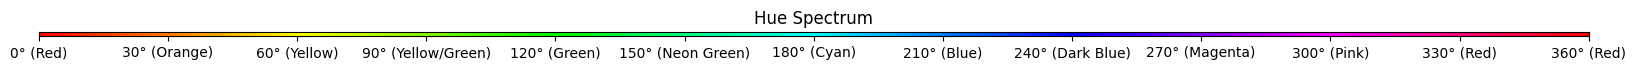

In [127]:
# Generate a spectrum of hues
hues = np.linspace(0, 1, 360)  # 360 values corresponding to hue angles
saturation = np.ones_like(hues)
value = np.ones_like(hues)

# Convert HSV to RGB
hsv_colors = np.stack([hues, saturation, value], axis=1)
rgb_colors = mcolors.hsv_to_rgb(hsv_colors)

# Plot the spectrum
plt.figure(figsize=(20, 2))
plt.imshow([rgb_colors], extent=[0, 360, 0, 1])
plt.yticks([])
plt.xticks(np.arange(0, 361, 30), labels=[
    "0° (Red)", "30° (Orange)", "60° (Yellow)", "90° (Yellow/Green)",
    "120° (Green)", "150° (Neon Green)", "180° (Cyan)", "210° (Blue)",
    "240° (Dark Blue)", "270° (Magenta)", "300° (Pink)", "330° (Red)", "360° (Red)"
])
plt.title("Hue Spectrum")
plt.show()


### Counting Colors

In [128]:
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'

# Convert the RGB cluster centers to HSV and classify them by tone
color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in all_cluster_centers]

# Count the occurrences of each tone
tone_counts = Counter(color_tones)

# Calculate the percentage of each tone
total_colors = len(all_cluster_centers)
tone_percentages = {tone: (count / total_colors) * 100 for tone, count in tone_counts.items()}

# Display the results
for tone, percentage in tone_percentages.items():
    print(f"{tone.capitalize()} tones: {percentage:.2f}%")


Yellow tones: 5.69%
Orange tones: 19.21%
Neon green tones: 4.58%
Yellow/green tones: 4.44%
Green tones: 3.43%
Red tones: 32.92%
Blue tones: 9.91%
Cyan tones: 15.00%
Magenta tones: 1.48%
Pink tones: 1.25%
Dark blue tones: 2.08%


### Sanity Check

In [129]:
# Sanity check: Ensure total counts match the number of colors
total_count = sum(tone_counts.values())
if total_count == total_colors:
    print("All colors are accounted for.")
    print("total_colors: "+str(total_count))
else:
    print(f"Warning: Mismatch in total counts. Expected {total_colors}, but got {total_count}.")

# Check for any "unknown" classifications
if 'unknown' in tone_counts:
    print(f"Warning: {tone_counts['unknown']} colors are classified as 'unknown'.")
else:
    print("No colors are classified as 'unknown'.")

# Print a sample of classified colors
print("Sample of classified colors:")
sample_size = min(10, len(all_cluster_centers))  # Adjust sample size as needed
for i in range(sample_size):
    r, g, b = all_cluster_centers[i]
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    tone = classify_color_by_tone(hsv)
    print(f"Color RGB({r}, {g}, {b}) -> HSV({hsv[0]*360:.2f}°, {hsv[1]:.2f}, {hsv[2]:.2f}) -> Tone: {tone}")

# Sort tones by percentage in descending order
sorted_tones = sorted(tone_percentages.items(), key=lambda x: x[1], reverse=True)

# Display the summary of counts and percentages in sorted order
print("\nSummary of tone counts and percentages (sorted by percentage):")
for tone, percentage in sorted_tones:
    count = tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")


All colors are accounted for.
total_colors: 2160
No colors are classified as 'unknown'.
Sample of classified colors:
Color RGB(135.6014492753623, 138.75362318840578, 108.57246376811594) -> HSV(66.27°, 0.22, 0.54) -> Tone: yellow
Color RGB(85.70666666666666, 73.62666666666667, 46.57999999999998) -> HSV(41.48°, 0.46, 0.34) -> Tone: orange
Color RGB(189.67857142857144, 197.8928571428571, 161.1071428571428) -> HSV(73.40°, 0.19, 0.78) -> Tone: yellow
Color RGB(24.255555555555546, 24.955555555555577, 17.64444444444443) -> HSV(65.74°, 0.29, 0.10) -> Tone: yellow
Color RGB(101.45205479452055, 95.06849315068493, 68.02054794520548) -> HSV(48.54°, 0.33, 0.40) -> Tone: orange
Color RGB(80.64383561643837, 96.9041095890411, 92.39041095890411) -> HSV(163.34°, 0.17, 0.38) -> Tone: neon green
Color RGB(164.1742424242424, 155.24242424242425, 115.31818181818181) -> HSV(49.03°, 0.30, 0.64) -> Tone: orange
Color RGB(51.857142857142854, 47.87755102040817, 30.59863945578229) -> HSV(48.77°, 0.41, 0.20) -> Ton

### Determining if There is a General Filter

To determine if there is a filter or bias in the colors, we can analyze the distribution of colors in terms of their saturation, brightness, contrast and color temperature. This analysis can help identify whether the colors are predominantly muted, bright, dark, or vibrant, which could indicate the presence of a color filter or a specific aesthetic trend in the movies.

**Steps to Analyze**
1. Calculate Saturation and Brightness: Convert the RGB colors to the HSV color space and extract the saturation and value (brightness) components.

3. Calculate contrast alongside saturation and brightness: Contrast in this context can be interpreted as the difference between the brightest and darkest areas in an image or color. However, for individual colors, we can approximate "contrast" by considering how far the brightness (value) deviates from the mid-point (which would be 0.5 on a scale of 0 to 1).

4. Calculate Color Temperature: Color temperature describes the warmth or coolness of a color, typically measured in Kelvin (K). While exact color temperature calculations are complex and often require specific lighting conditions, we can approximate the warmth or coolness of colors by examining their RGB values.

5. Visualize the Distribution: Plot histograms and scatter plots of saturation, brightness, contrast and color temperature to observe their distribution.

3. Cluster Analysis: We can perform clustering based on these features to identify common trends.

### Distribution of Saturation, Brightness, and Contrast

In [130]:
saturation_values = []
brightness_values = []
contrast_values = []

for r, g, b in all_cluster_centers:
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    saturation_values.append(hsv[1])
    brightness_values.append(hsv[2])
    
    # Calculate contrast as the difference from mid-brightness (0.5)
    contrast = abs(hsv[2] - 0.5)
    contrast_values.append(contrast)

# Print a sample to verify
print("Sample of saturation, brightness, and contrast values:")
for i in range(10):
    print(f"Color RGB({all_cluster_centers[i]}) -> Saturation: {saturation_values[i]:.2f}, Brightness: {brightness_values[i]:.2f}, Contrast: {contrast_values[i]:.2f}")


Sample of saturation, brightness, and contrast values:
Color RGB([135.60144928 138.75362319 108.57246377]) -> Saturation: 0.22, Brightness: 0.54, Contrast: 0.04
Color RGB([85.70666667 73.62666667 46.58      ]) -> Saturation: 0.46, Brightness: 0.34, Contrast: 0.16
Color RGB([189.67857143 197.89285714 161.10714286]) -> Saturation: 0.19, Brightness: 0.78, Contrast: 0.28
Color RGB([24.25555556 24.95555556 17.64444444]) -> Saturation: 0.29, Brightness: 0.10, Contrast: 0.40
Color RGB([101.45205479  95.06849315  68.02054795]) -> Saturation: 0.33, Brightness: 0.40, Contrast: 0.10
Color RGB([80.64383562 96.90410959 92.39041096]) -> Saturation: 0.17, Brightness: 0.38, Contrast: 0.12
Color RGB([164.17424242 155.24242424 115.31818182]) -> Saturation: 0.30, Brightness: 0.64, Contrast: 0.14
Color RGB([51.85714286 47.87755102 30.59863946]) -> Saturation: 0.41, Brightness: 0.20, Contrast: 0.30
Color RGB([116.44886364 119.0625      92.19318182]) -> Saturation: 0.23, Brightness: 0.47, Contrast: 0.03
Col

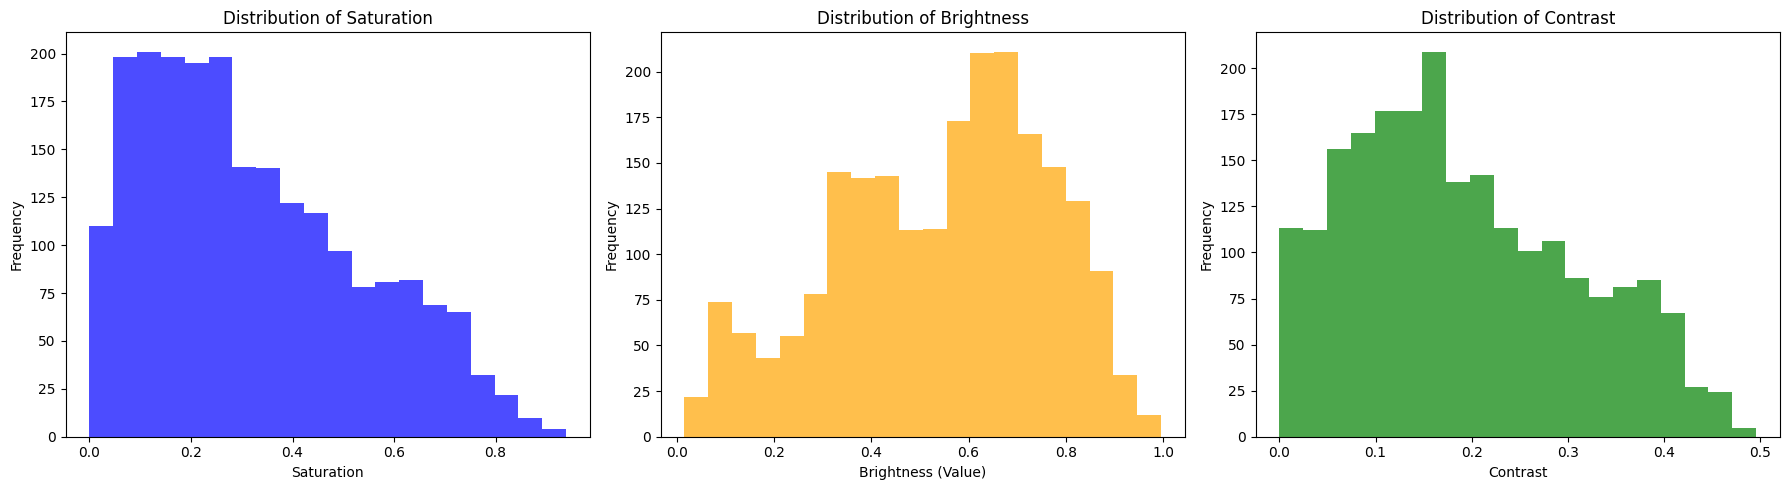

In [131]:

# Plot the distribution of saturation
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(saturation_values, bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Saturation')
plt.xlabel('Saturation')
plt.ylabel('Frequency')

# Plot the distribution of brightness
plt.subplot(1, 3, 2)
plt.hist(brightness_values, bins=20, color='orange', alpha=0.7)
plt.title('Distribution of Brightness')
plt.xlabel('Brightness (Value)')
plt.ylabel('Frequency')

# Plot the distribution of contrast
plt.subplot(1, 3, 3)
plt.hist(contrast_values, bins=20, color='green', alpha=0.7)
plt.title('Distribution of Contrast')
plt.xlabel('Contrast')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Saturation:** The distribution of saturation in Hindi films shows a broader range, but with a peak in the lower-medium range. This suggests that a significant number of scenes have muted or moderately saturated colors, which could indicate a focus on more natural or subdued color palettes. *But in combination with the high brightness it may lead to brighter colors being percieved*

**Brightness:** The brightness distribution is relatively balanced, with a slight peak in the higher range. This indicates that Hindi films often feature well-lit scenes with moderate to high brightness, which can convey a lively or vibrant atmosphere.

**Contrast:** The contrast distribution shows a peak in the low to medium range, indicating that Hindi films tend to avoid harsh contrasts. This might reflect a preference for softer transitions between light and dark areas in the frame, contributing to a more visually pleasing and less stark visual style.

### Distribution of Color Temperature

Sample of color temperature values:
Color RGB([135.60144928 138.75362319 108.57246377]) -> Color Temperature: 5211.99 K
Color RGB([85.70666667 73.62666667 46.58      ]) -> Color Temperature: 5306.88 K
Color RGB([189.67857143 197.89285714 161.10714286]) -> Color Temperature: 5224.09 K
Color RGB([24.25555556 24.95555556 17.64444444]) -> Color Temperature: 5051.85 K
Color RGB([101.45205479  95.06849315  68.02054795]) -> Color Temperature: 5262.21 K
Color RGB([80.64383562 96.90410959 92.39041096]) -> Color Temperature: 4907.87 K
Color RGB([164.17424242 155.24242424 115.31818182]) -> Color Temperature: 5383.18 K
Color RGB([51.85714286 47.87755102 30.59863946]) -> Color Temperature: 5166.73 K
Color RGB([116.44886364 119.0625      92.19318182]) -> Color Temperature: 5190.24 K
Color RGB([130.31666667 152.23333333 142.75833333]) -> Color Temperature: 4902.42 K


/var/folders/m7/r7m7ht2j7jbfb00kv5p9d0q00000gn/T/ipykernel_81175/4230416526.py:27: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



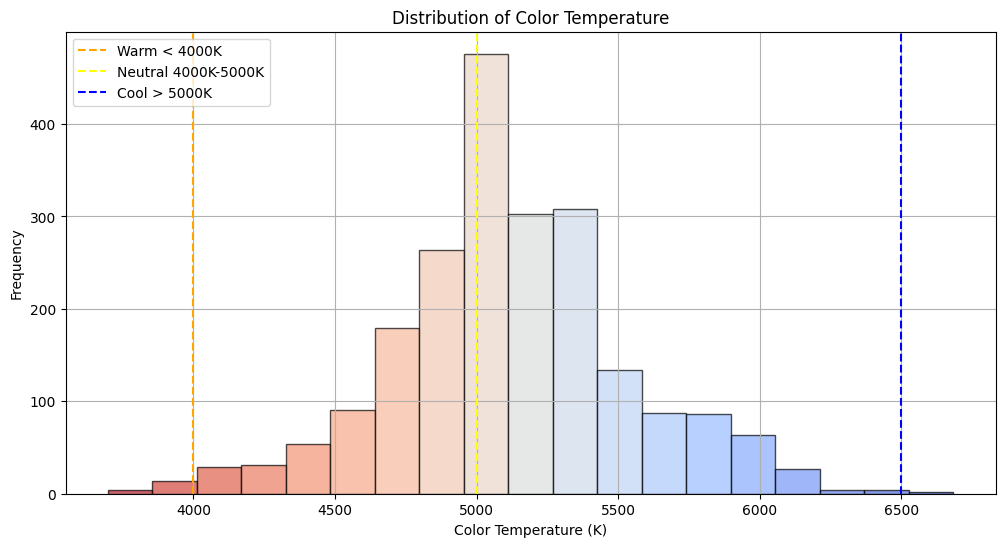

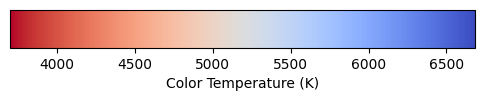

In [132]:

def calculate_color_temperature(r, g, b):
    # Approximate color temperature calculation (based on RGB)
    # This is a simplified model; more complex models use chromaticity calculations
    if r > b:
        # Warmer colors
        temperature = 5000 + (r - b) * 2000 / 255
    else:
        # Cooler colors
        temperature = 5000 - (b - r) * 2000 / 255
    return temperature

# Apply to all cluster centers
color_temperatures = [calculate_color_temperature(r, g, b) for r, g, b in all_cluster_centers]

# Print a sample to verify
print("Sample of color temperature values:")
for i in range(10):
    print(f"Color RGB({all_cluster_centers[i]}) -> Color Temperature: {color_temperatures[i]:.2f} K")

# Define temperature ranges
warm_threshold = 4000  # Below 4000K: warm
neutral_threshold = 5000  # 4000K-5000K: neutral
cool_threshold = 6500  # 5000K-6500K: cool
bins = np.linspace(min(color_temperatures), max(color_temperatures), 20)

# Create a reversed colormap for correct color temperature mapping
colormap = cm.get_cmap('coolwarm_r')  # Reverse the colormap to match color temperature convention
norm = plt.Normalize(min(color_temperatures), max(color_temperatures))

# Calculate the histogram data
hist, bin_edges = np.histogram(color_temperatures, bins=bins)

# Get the colors for each bin based on the average temperature in that bin
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
colors = [colormap(norm(center)) for center in bin_centers]

# Plot each bar manually with its corresponding color
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, hist, width=np.diff(bin_edges), color=colors, edgecolor='black', alpha=0.7)

plt.title('Distribution of Color Temperature')
plt.xlabel('Color Temperature (K)')
plt.ylabel('Frequency')

# Annotate ranges
plt.axvline(x=warm_threshold, color='orange', linestyle='--', label='Warm < 4000K')
plt.axvline(x=neutral_threshold, color='yellow', linestyle='--', label='Neutral 4000K-5000K')
plt.axvline(x=cool_threshold, color='blue', linestyle='--', label='Cool > 5000K')

plt.legend(loc='upper left')
plt.grid(True)

# Create a standalone colorbar that matches the colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), cax=ax, orientation='horizontal')
cbar.set_label('Color Temperature (K)')
plt.show()



The color temperature distribution shows a strong peak around the neutral to cool range (5000-5500K), but we do see more warmer colours here than we do in English film, which may be because warmer colors tend to complete darker skins tones better but this is a generalization.

### Scatter Plots of Saturation vs. Brightness with Color Temperature and Contrast

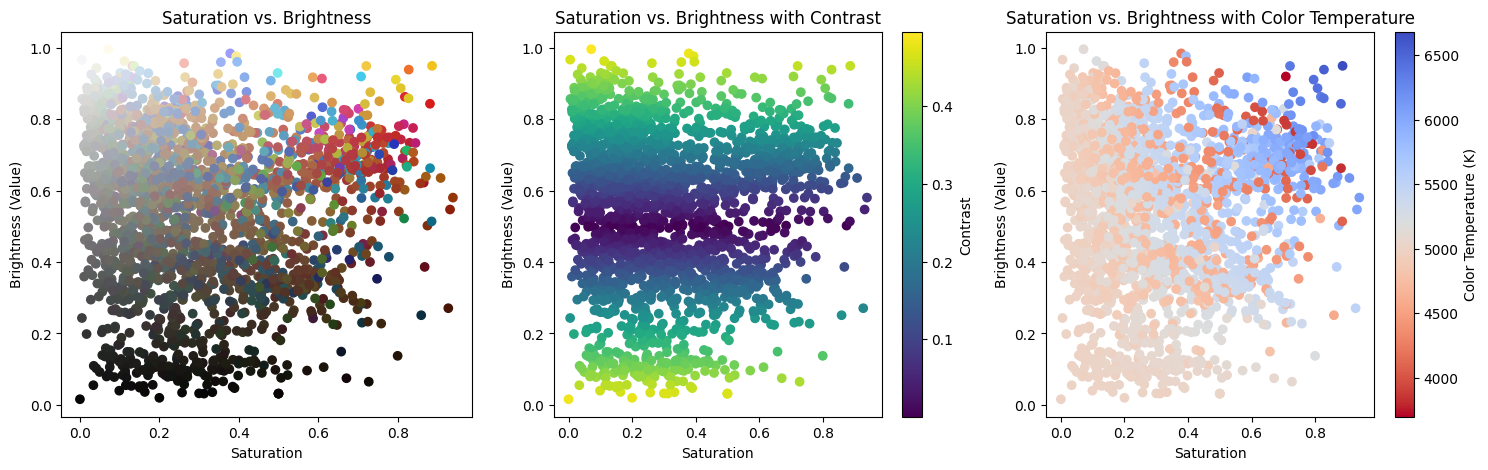

In [133]:
plt.figure(figsize=(18, 5))

# Scatter plot of saturation vs. brightness
# plt.figure(figsize=(7, 7))
plt.subplot(1,3,1)
plt.scatter(saturation_values, brightness_values, c=[mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in all_cluster_centers], alpha=1)
plt.title('Saturation vs. Brightness')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')

# Scatter plot of Saturation vs. Brightness with Contrast as color
#plt.figure(figsize=(7, 7))
plt.subplot(1,3,2)
plt.scatter(saturation_values, brightness_values, c=contrast_values, cmap='viridis', alpha=1)
plt.colorbar(label='Contrast')
plt.title('Saturation vs. Brightness with Contrast')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')

# Scatter plot of Saturation vs. Brightness with Color Temperature as color
plt.subplot(1,3,3)
plt.scatter(saturation_values, brightness_values, c=color_temperatures, cmap='coolwarm_r', alpha=1)
plt.colorbar(label='Color Temperature (K)')
plt.title('Saturation vs. Brightness with Color Temperature')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')


plt.show()

**Saturation vs. Brightness:** The scatter plot shows a dense cluster of points with low to medium saturation and varying brightness levels. This suggests that Hindi films often mix muted colors with a range of brightness levels, allowing for both vibrant and more toned-down scenes within the same visual style.

**Saturation vs. Brightness with Contrast:** Adding contrast as a third dimension reveals that scenes with medium contrast tend to dominate. This indicates a preference for balance, with neither too flat nor too dramatic visual contrasts, ensuring that scenes remain visually coherent.

    - Medium contrast is often used to maintain a natural or realistic look while still providing enough definition to make the image interesting. This is particularly effective in genres like romance, where the focus is on emotional storytelling rather than stark visual effects. 

**Saturation vs. Brightness with Color Temperature:** This plot highlights that cooler scenes (higher color temperatures) often correlate with higher brightness levels, while neutral or warmer scenes are more likely to have medium to lower brightness. This suggests that cooler tones are used to highlight or emphasize certain elements within brighter scenes.

### Feature Clustering

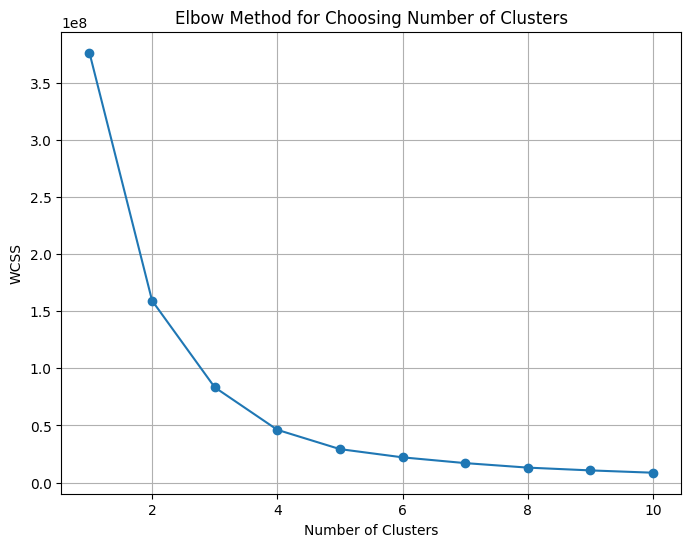

In [134]:
# Combine the features into a single dataset
combined_filter_data = np.column_stack((saturation_values, brightness_values, color_temperatures, contrast_values))

# Calculate WCSS for a range of cluster numbers
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(combined_filter_data)
    wcss.append(kmeans.inertia_)

# Plot the WCSS to find the elbow point
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Choosing Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [135]:
# Perform K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(combined_filter_data)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



### 3D Clustering of Saturation, Brightness, and Color Temperature

In [136]:
# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=combined_filter_data[:, 0],  # Saturation
    y=combined_filter_data[:, 1],  # Brightness
    z=combined_filter_data[:, 2],  # Color Temperature
    mode='markers',
    marker=dict(
        size=5,
        color=clusters,  # Color points by cluster
        colorscale='Viridis',  # Color scale
        opacity=0.8
    )
)])

# Add labels and title
fig.update_layout(
    title='3D Clustering of Saturation, Brightness, and Color Temperature',
    scene=dict(
        xaxis_title='Saturation',
        yaxis_title='Brightness',
        zaxis_title='Color Temperature'
    ),
    width=1000,  # Set the width of the plot
    height=700   # Set the height of the plot
)

# Display the plot
fig.show()


**Why Brightness is Not Included:** In this 3D plot, brightness was not chosen as one of the axes because it is highly correlated with saturation and color temperature. Including it might not provide additional insights and could make the clusters harder to interpret.

The fan-like spread along the Saturation and Brightness axes indicates that as brightness increases, the points spread out more in terms of saturation. This suggests that brighter scenes tend to have more variation in color saturation.

The spread along the Color Temperature axis shows how clusters are organized around specific temperature ranges, with distinct separation between warm and cool scenes.

The 3D plot shows distinct clusters, with clear separation based on the three dimensions. This indicates that Hindi films employ a variety of color grading techniques, resulting in distinct visual styles that can be categorized based on their saturation, brightness, and color temperature.

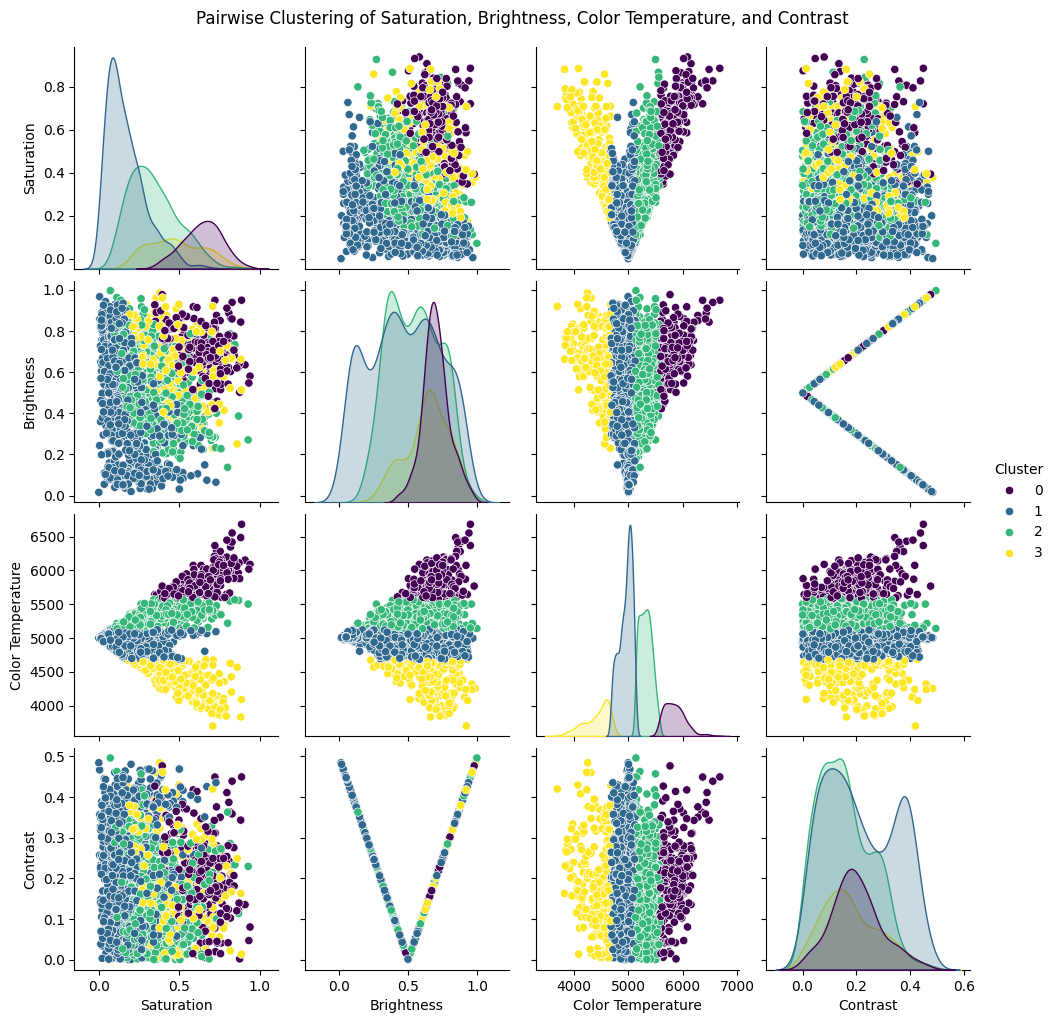

In [137]:
# Create a DataFrame for easier plotting
filters_df = pd.DataFrame({
    'Saturation': saturation_values,
    'Brightness': brightness_values,
    'Color Temperature': color_temperatures,
    'Contrast': contrast_values,
    'Cluster': clusters
})

# Pairplot to visualize relationships
sns.pairplot(filters_df, hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pairwise Clustering of Saturation, Brightness, Color Temperature, and Contrast', y=1.02)
plt.show()


### Understanding the Pairplot

#### Diagonals: Kernel Density Estimations (KDEs)

- The diagonals show the distribution of each feature (Saturation, Brightness, Color Temperature, and Contrast) within each cluster. Each diagonal subplot uses a Kernel Density Estimation (KDE) to smooth out the distribution, providing an estimate of the probability density function for the feature within each cluster.

#### Off-Diagonal Plots: Pairwise Relationships

- For the off diagonals, what we're really seeing is that color temperature is the best feature for grouping colors into similar clusters, but since we havent sorted the colors by segment this really doesnt tell us much more


### What are the Cluster's Average Values

In [138]:
def categorize_value(value, feature):
    if feature == 'Saturation' or feature == 'Brightness':
        if value < 0.3:
            return 'Low'
        elif value < 0.6:
            return 'Medium'
        else:
            return 'High'
    elif feature == 'Color Temperature':
        if value < 4000:
            return 'Warm'
        elif value < 5000:
            return 'Neutral'
        else:
            return 'Cool'
    elif feature == 'Contrast':
        if value < 0.2:
            return 'Low'
        elif value < 0.4:
            return 'Medium'
        else:
            return 'High'

# Calculate the mean values for each cluster
cluster_means = filters_df.groupby('Cluster').mean()

# Print the results
print("Average Values for Each Cluster:")
print(cluster_means)

# Apply the categorization
categorized_means = cluster_means.apply(lambda col: [categorize_value(val, col.name) for val in col])
print("")
# Print the human-interpretable results
print("Human-Interpretable Average Values for Each Cluster:")
print(categorized_means)

Average Values for Each Cluster:
         Saturation  Brightness  Color Temperature  Contrast
Cluster                                                     
0          0.642219    0.698257        5853.464342  0.200221
1          0.169571    0.472770        4950.135184  0.216821
2          0.340053    0.544248        5318.839909  0.157401
3          0.479393    0.639417        4419.024757  0.181298

Human-Interpretable Average Values for Each Cluster:
        Saturation Brightness Color Temperature Contrast
Cluster                                                 
0             High       High              Cool   Medium
1              Low     Medium           Neutral   Medium
2           Medium     Medium              Cool      Low
3           Medium       High           Neutral      Low


1. Cluster 0: 
    - Likely represents scenes that are vibrant and well-lit, with cooler tones and moderate contrast. These could be energetic, visually striking scenes, possibly for action or dramatic moments.

2. Cluster 1: 
    - Represents more subdued scenes with muted colors, medium brightness, and neutral color temperatures. These might be used for more intimate or down-to-earth moments.

3. Cluster 2:
    - This cluster might represent scenes that are modern and stylish, with cool tones and minimal contrast, possibly used in urban or sleek settings.

4. Cluster 3:
    - Likely represents scenes that are bright and inviting, with neutral tones and low contrast, creating a pleasant, welcoming atmosphere.

**Must Keep in mind that while i can group these colors into certain clusters i cannot make assumptions about whether they actually represent certain segments of the film as ive not done this in a segmented format. To achieve that id need to do a clustering on specific segments of the film rather than as a whole**

### Final K-Means Clustering

Lets now do a K_Means analysis on all of our colors (that we got using K_Means on each segment of each movie) to get a set of 15/20 colors to represent english film.

In [139]:
# Define the number of final clusters 
final_num_clusters = 30

# Perform the final K-Means clustering on the combined cluster centers
final_kmeans = KMeans(n_clusters=final_num_clusters, n_init=10, random_state=42)
final_kmeans.fit(all_cluster_centers)

# Get the final cluster centers (representing the dominant colors)
final_colors = final_kmeans.cluster_centers_

### Visualization

In [140]:
# Convert RGB values to HEX
final_hex_colors = [mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in final_colors]

# Optional: Sort the final colors by hue to make them more visually organized
hsv_colors = [mcolors.rgb_to_hsv([r/255, g/255, b/255]) for r, g, b in final_colors]
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_final_hex_colors = [final_hex_colors[i] for i in sorted_indices]

# Set the number of columns for the grid display
num_columns = 5  # Adjust as needed

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_final_hex_colors) / num_columns)

# Create an HTML table with a grid layout
html_table = '<table style="border-collapse: collapse;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_final_hex_colors):
            hex_color = sorted_final_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:50px; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'

# Display the HTML table with the final colors
display(HTML(html_table))

,#b13e39,,#c1bfbe,,#953d24,,#a8674d,,#5a3a2b
,#836753,,#bc9679,,#918170,,#c4b09c,,#665743
,#342d25,,#d8c7a7,,#9f988b,,#171613,,#d4b043
,#82a051,,#434943,,#6a706c,,#d6dad9,,#9ea8a9
,#348ea7,,#63a5cb,,#4b5b65,,#2b4658,,#607e97
,#838f9e,,#9db3d1,,#4654ab,,#c044ba,,#bf4269
